In [23]:
##################################################
# Analyse des données du TITANIC
##################################################
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_excel('titanic3.xls')
data.shape
print(data)

      pclass  survived                                             name  \
0          1         1                    Allen, Miss. Elisabeth Walton   
1          1         1                   Allison, Master. Hudson Trevor   
2          1         0                     Allison, Miss. Helen Loraine   
3          1         0             Allison, Mr. Hudson Joshua Creighton   
4          1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)   
...      ...       ...                                              ...   
1304       3         0                             Zabour, Miss. Hileni   
1305       3         0                            Zabour, Miss. Thamine   
1306       3         0                        Zakarian, Mr. Mapriededer   
1307       3         0                              Zakarian, Mr. Ortin   
1308       3         0                               Zimmerman, Mr. Leo   

         sex      age  sibsp  parch  ticket      fare    cabin embarked boat  \
0     female  29.00

In [75]:
import xlrd
print(xlrd.__version__)
import pandas as pd

data = pd.read_excel("titanic3.xls")

print(data.shape)
print(data.columns)
data.head()

2.0.2
(1309, 14)
Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'],
      dtype='str')


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [76]:
# Supprimer les colonnes qui ne sont pas nécessaires pour l'analyse
data = data.drop([
    'sibsp',
    'parch',
    'ticket',
    'fare',
    'cabin',
    'embarked',
    'boat',
    'body',
    'home.dest'
], axis=1, errors='ignore')
print(data.columns.tolist())

['pclass', 'survived', 'name', 'sex', 'age']


In [77]:
data.describe

<bound method NDFrame.describe of       pclass  survived                                             name  \
0          1         1                    Allen, Miss. Elisabeth Walton   
1          1         1                   Allison, Master. Hudson Trevor   
2          1         0                     Allison, Miss. Helen Loraine   
3          1         0             Allison, Mr. Hudson Joshua Creighton   
4          1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)   
...      ...       ...                                              ...   
1304       3         0                             Zabour, Miss. Hileni   
1305       3         0                            Zabour, Miss. Thamine   
1306       3         0                        Zakarian, Mr. Mapriededer   
1307       3         0                              Zakarian, Mr. Ortin   
1308       3         0                               Zimmerman, Mr. Leo   

         sex      age  
0     female  29.0000  
1       male   0.

In [78]:
data = data.dropna(axis=0)
data.shape
data.describe()

,pclass,survived,age
count,1046.000000,1046.000000,1046.000000
mean,2.207457,0.408222,29.881135
std,0.841497,0.491740,14.413500
min,1.000000,0.000000,0.166700
25%,1.000000,0.000000,21.000000
50%,2.000000,0.000000,28.000000
75%,3.000000,1.000000,39.000000
max,3.000000,1.000000,80.000000


<Axes: xlabel='pclass'>

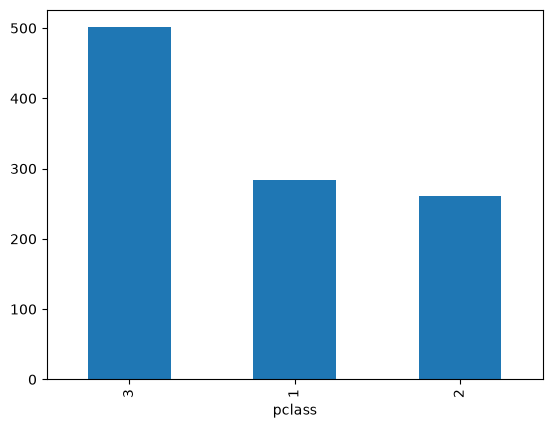

In [79]:
data['pclass'].value_counts().plot.bar()

<Axes: >

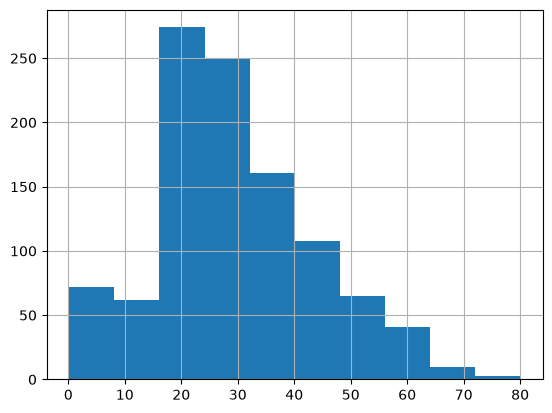

In [80]:
data['age'].hist()

In [82]:
data.groupby(['sex', 'pclass']).mean(numeric_only=True)

survived        age
sex    pclass                     
female 1       0.962406  37.037594
       2       0.893204  27.499191
       3       0.473684  22.185307
male   1       0.350993  41.029250
       2       0.145570  30.815401
       3       0.169054  25.962273

In [70]:
##################################################
# DATAFRAMES ET SÉRIES dans les DÉTAILS
##################################################
import pandas as pd

data = pd.read_excel('titanic3.xls')

data = data.set_index('name')

print(data['age'])



name
Allen, Miss. Elisabeth Walton                      29.0000
Allison, Master. Hudson Trevor                      0.9167
Allison, Miss. Helen Loraine                        2.0000
Allison, Mr. Hudson Joshua Creighton               30.0000
Allison, Mrs. Hudson J C (Bessie Waldo Daniels)    25.0000
                                                    ...   
Zabour, Miss. Hileni                               14.5000
Zabour, Miss. Thamine                                  NaN
Zakarian, Mr. Mapriededer                          26.5000
Zakarian, Mr. Ortin                                27.0000
Zimmerman, Mr. Leo                                 29.0000
Name: age, Length: 1309, dtype: float64


In [71]:
# Sélectionner les passagers âgés de moins de 18 ans,
# puis compter le nombre de passagers dans chaque classe (Pclass)
data[data['age'] < 18]['pclass'].value_counts()

pclass
3    106
2     33
1     15
Name: count, dtype: int64

In [85]:
# Sélectionner les passagers âgés de moins de 18 ans
# puis les regrouper selon leur classe (pclass)
# et compter les différentes valeurs pour chaque groupe
# data[data['age'] < 18].groupby(['sex','pclass']).value_counts()
data[data['age'] < 18].groupby(['sex','pclass']).mean(numeric_only=True)

survived        age
sex    pclass                     
female 1       0.875000  14.125000
       2       1.000000   8.273150
       3       0.543478   8.416667
male   1       0.857143   9.845243
       2       0.733333   6.222220
       3       0.233333   9.838888

In [88]:
data.iloc[0:2, 0:2]

,pclass,survived
0,1,1
1,1,1


In [87]:
data.loc[0:2, 'age']

0    29.0000
1     0.9167
2     2.0000
Name: age, dtype: float64